### Loading the Dataset

In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.6 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/36.6 MB 11.4 MB/s eta 0:00:03
   ------- -------------------------------- 6.6/36.6 MB 10.6 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.6 MB 10.7 MB/s eta 0:00:03
   ----------- ---------------------------- 10.7/36.6 MB 10.5 MB/s eta 0:00:03
   -------------- ------------------------- 12.8/36.6 MB 10.3 MB/s eta 0:00:03
   ---------------- ----------------------- 14.7/36.6 MB 10.3 MB/s eta 0:00:03
   ------------------ --------------------- 17.0/36.6 MB 10.2 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/36.6 MB 10.3 MB/s eta 0:00:02
   ----------------------- ---------------- 21.5/36.6 MB 10.3 MB/s eta 0:00:02
   ------------------------ --------------- 22.5/36.6 MB 10.3 MB/s eta 0:00:02
   ------------------------- -------------- 23.6/36.6 MB 9.6 MB/s


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\AmaanAlam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [33]:
import scipy

print(scipy.__version__)

1.17.1


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\AmaanAlam\OneDrive - ProcDNA Analytics Pvt. Ltd\Desktop\Abbott AB Testing\abbott_cgm_ab_testing_dataset.csv")

df.head()

,patient_id,age,gender,diabetes_type,state,device,days_since_signup,campaign_group,notification_open,weekly_sessions,weekly_scan_count,avg_session_time,retained_30_days,prescription_refill,revenue
0,P100000,38,Female,Type 1,Florida,Libre 3,349,B,1,8.9,14,13.9,0,0,0.00
1,P100001,74,Female,Type 2,New York,Libre 2,436,A,0,7.0,11,12.8,1,1,148.87
2,P100002,55,Male,Type 1,California,Libre 2,48,D,1,5.4,14,15.1,0,0,0.00
3,P100003,48,Male,Type 2,Florida,Libre 2,656,A,1,5.1,8,11.7,1,0,0.00
4,P100004,28,Male,Type 1,Illinois,Libre 2,708,B,0,7.7,11,10.3,1,1,166.00


### Basic Data Checks

In [3]:
print(df.shape)

(100000, 15)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   patient_id           100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   diabetes_type        100000 non-null  object 
 4   state                100000 non-null  object 
 5   device               100000 non-null  object 
 6   days_since_signup    100000 non-null  int64  
 7   campaign_group       100000 non-null  object 
 8   notification_open    100000 non-null  int64  
 9   weekly_sessions      100000 non-null  float64
 10  weekly_scan_count    100000 non-null  int64  
 11  avg_session_time     100000 non-null  float64
 12  retained_30_days     100000 non-null  int64  
 13  prescription_refill  100000 non-null  int64  
 14  revenue              100000 non-null  float64
dtypes: float64(3), int

In [5]:
df.isnull().sum()

patient_id             0
age                    0
gender                 0
diabetes_type          0
state                  0
device                 0
days_since_signup      0
campaign_group         0
notification_open      0
weekly_sessions        0
weekly_scan_count      0
avg_session_time       0
retained_30_days       0
prescription_refill    0
revenue                0
dtype: int64

No missing values were identified across the dataset, ensuring complete observations for all patients and eliminating the need for data imputation.

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate records were detected, confirming that each patient appears only once in the dataset.

In [8]:
df.describe()

,age,days_since_signup,notification_open,weekly_sessions,weekly_scan_count,avg_session_time,retained_30_days,prescription_refill,revenue
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,44.534350,379.882080,0.495720,6.396529,11.348500,10.553906,0.792560,0.722990,112.066690
std,15.509613,202.329149,0.499984,1.613204,2.646749,2.106008,0.405475,0.447524,69.758345
min,18.000000,30.000000,0.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000
25%,33.000000,205.000000,0.000000,5.300000,10.000000,9.100000,1.000000,0.000000,0.000000
50%,43.000000,379.000000,0.000000,6.400000,11.000000,10.500000,1.000000,1.000000,149.230000
75%,55.000000,556.000000,1.000000,7.500000,13.000000,12.000000,1.000000,1.000000,159.640000
max,80.000000,730.000000,1.000000,12.700000,22.000000,20.300000,1.000000,1.000000,170.000000


Summary statistics indicate that all numerical variables fall within realistic ranges, with no apparent outliers or invalid values requiring correction.

### Verifying Randomization

In [9]:
df["campaign_group"].value_counts()

campaign_group
C    25100
A    25076
B    24985
D    24839
Name: count, dtype: int64

In [10]:
df["gender"].value_counts()

gender
Male      51847
Female    48153
Name: count, dtype: int64

In [11]:
df["diabetes_type"].value_counts()

diabetes_type
Type 2    65062
Type 1    34938
Name: count, dtype: int64

All categorical variables contain the expected levels with consistent naming conventions.

In [12]:
binary_columns = ["notification_open", "retained_30_days", "prescription_refill"]

for col in binary_columns:
    print(col)
    print(df[col].value_counts())
    print()

notification_open
notification_open
0    50428
1    49572
Name: count, dtype: int64

retained_30_days
retained_30_days
1    79256
0    20744
Name: count, dtype: int64

prescription_refill
prescription_refill
1    72299
0    27701
Name: count, dtype: int64



Binary outcome variables were validated successfully, confirming they contain only valid values (0 and 1).

Data Validation Summary

Successfully loaded 100,000 patient records with 15 variables.
No missing values or duplicate records were identified.
All variables had appropriate data types.
Numerical variables were within expected ranges.
Categorical and binary variables contained only valid values.
The dataset passed all validation checks and was deemed suitable for exploratory analysis and A/B testing.

# EXPLORATORY DATA ANALYSIS (EDA)

Objective

Explore patient demographics, campaign distribution, and key performance metrics to understand trends and verify that the experiment behaves as expected.

A) Campaign Group Distribution

In [14]:
campaign_dist = df["campaign_group"].value_counts().sort_index()

print(campaign_dist)

campaign_group
A    25076
B    24985
C    25100
D    24839
Name: count, dtype: int64


In [15]:
(df["campaign_group"].value_counts(normalize=True).mul(100).round(2))

campaign_group
C    25.10
A    25.08
B    24.98
D    24.84
Name: proportion, dtype: float64

B) Age Distribution

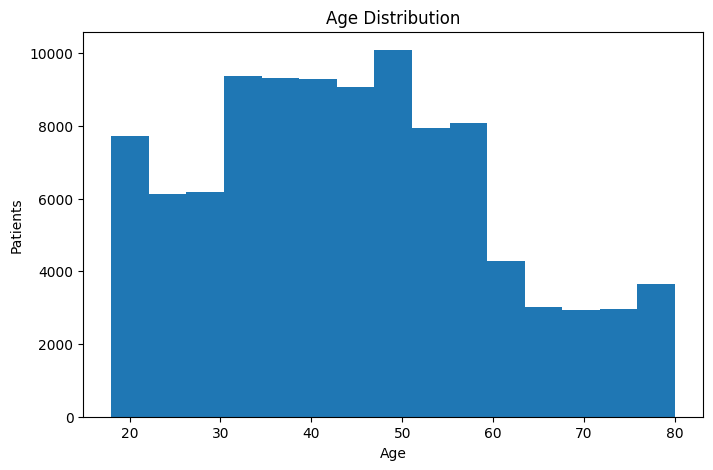

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")

plt.show()

The study population primarily consists of middle-aged adults, with ages ranging from 18 to 80 years. No abnormal age values were observed.

C) Gender Distribution

gender
Male      51847
Female    48153
Name: count, dtype: int64


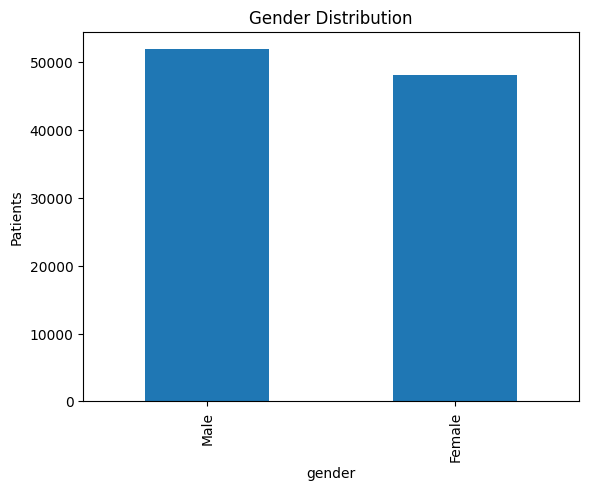

In [20]:
gender = df["gender"].value_counts()

print(gender)

gender.plot(kind="bar")

plt.title("Gender Distribution")
plt.ylabel("Patients")

plt.show()

D) Diabetes Type Distribution

diabetes_type
Type 2    65062
Type 1    34938
Name: count, dtype: int64


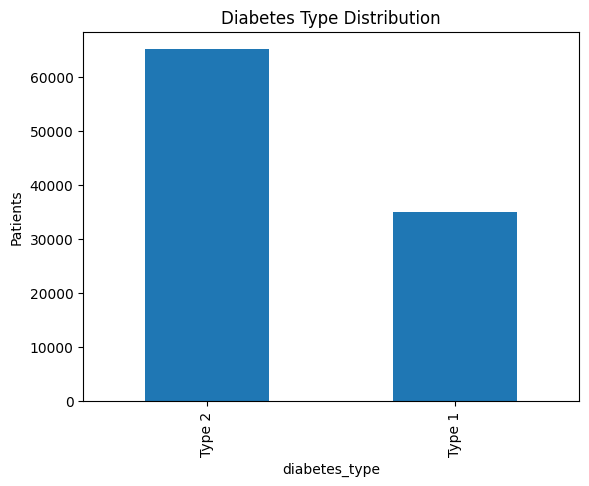

In [21]:
diabetes = df["diabetes_type"].value_counts()

print(diabetes)

diabetes.plot(kind="bar")

plt.title("Diabetes Type Distribution")
plt.ylabel("Patients")

plt.show()

The majority of patients have Type 2 diabetes, which aligns with expected real-world prevalence.

E) Device Distribution

device
Libre 2    59926
Libre 3    40074
Name: count, dtype: int64


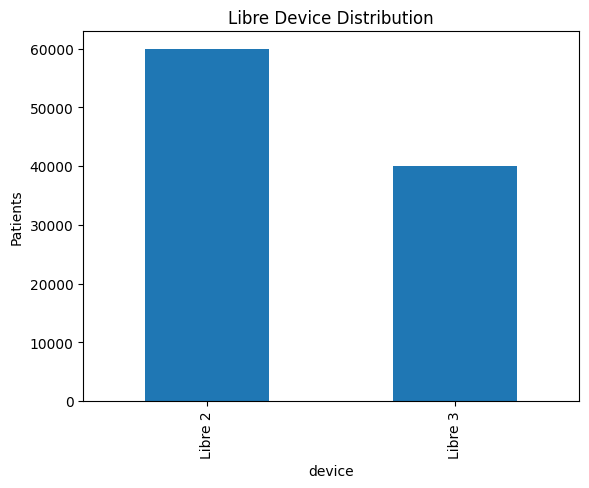

In [22]:
device = df["device"].value_counts()

print(device)

device.plot(kind="bar")

plt.title("Libre Device Distribution")
plt.ylabel("Patients")

plt.show()

Libre 2 users represent the larger share of the study population, consistent with the predefined sampling distribution.

F) State Distribution

state
Florida           10163
Ohio              10058
California        10044
New York          10009
Michigan           9999
Pennsylvania       9967
Texas              9959
North Carolina     9943
Georgia            9936
Illinois           9922
Name: count, dtype: int64


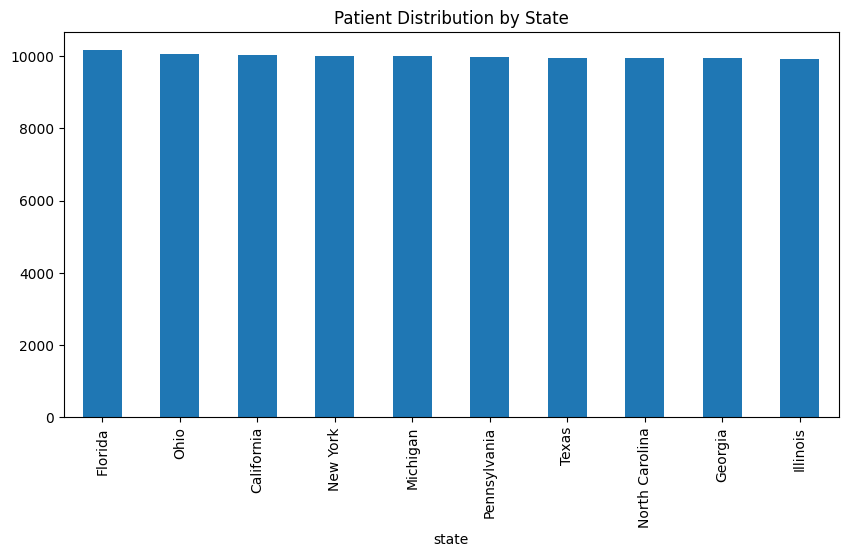

In [24]:
state = df["state"].value_counts()

print(state)

state.plot(kind="bar", figsize=(10, 5))

plt.title("Patient Distribution by State")

plt.show()

Patients are well distributed across the selected U.S. states, allowing campaign performance to be analyzed across different geographic regions.

G) Numerical Feature Summary

In [25]:
numerical_cols = ["weekly_sessions", "weekly_scan_count", "avg_session_time", "revenue"]

df[numerical_cols].describe()

,weekly_sessions,weekly_scan_count,avg_session_time,revenue
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.396529,11.348500,10.553906,112.066690
std,1.613204,2.646749,2.106008,69.758345
min,1.000000,2.000000,2.000000,0.000000
25%,5.300000,10.000000,9.100000,0.000000
50%,6.400000,11.000000,10.500000,149.230000
75%,7.500000,13.000000,12.000000,159.640000
max,12.700000,22.000000,20.300000,170.000000


Numerical variables fall within expected ranges, indicating realistic patient engagement and revenue values.

H) Distribution of Weekly Sessions

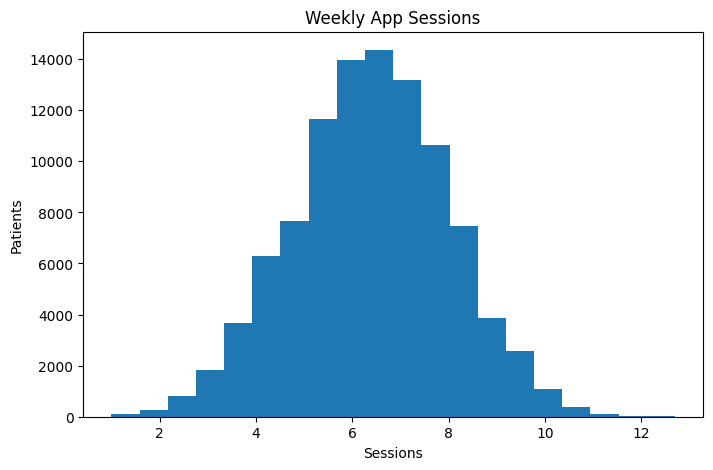

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(df["weekly_sessions"], bins=20)

plt.title("Weekly App Sessions")
plt.xlabel("Sessions")
plt.ylabel("Patients")

plt.show()

Most patients use the application between 4 and 8 times per week, suggesting consistent engagement among active users.

I) Distribution of Weekly Scan Count

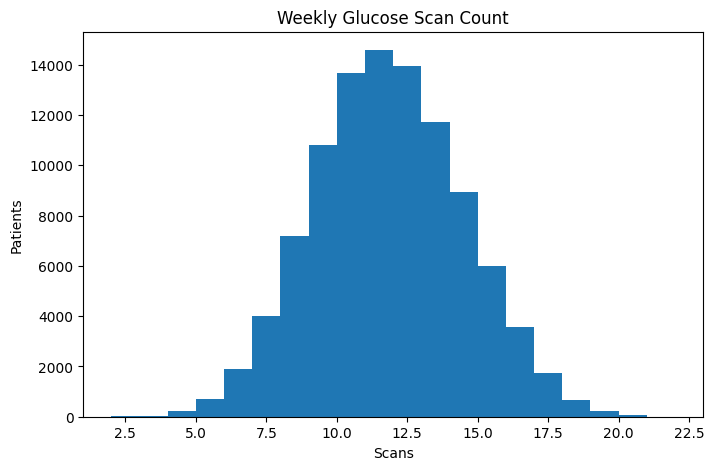

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["weekly_scan_count"], bins=20)

plt.title("Weekly Glucose Scan Count")
plt.xlabel("Scans")
plt.ylabel("Patients")

plt.show()

Weekly scan counts are centered around the expected range, with a moderate spread that reflects varying levels of patient adherence.

J) Revenue Distribution

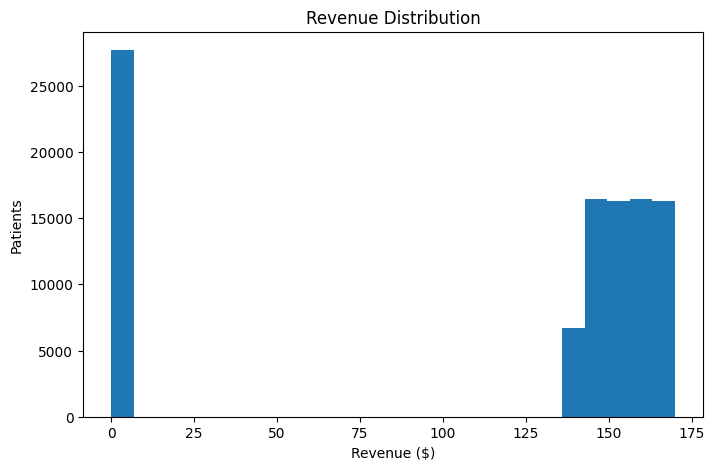

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(df["revenue"], bins=25)

plt.title("Revenue Distribution")
plt.xlabel("Revenue ($)")
plt.ylabel("Patients")

plt.show()

We see large spike at 0, since patients without a prescription refill generate no revenue. Revenue exhibits a zero-inflated distribution, reflecting that only patients who renewed their prescriptions contribute to revenue.

K) Correlation Analysis

In [29]:
corr = df[
    [
        "notification_open",
        "weekly_sessions",
        "weekly_scan_count",
        "retained_30_days",
        "prescription_refill",
        "revenue",
    ]
].corr()

corr

,notification_open,weekly_sessions,weekly_scan_count,retained_30_days,prescription_refill,revenue
notification_open,1.000000,0.291516,0.084425,0.019199,0.013986,0.014113
weekly_sessions,0.291516,1.000000,0.433403,0.087872,0.050477,0.050265
weekly_scan_count,0.084425,0.433403,1.000000,0.076989,0.032460,0.032289
retained_30_days,0.019199,0.087872,0.076989,1.000000,0.079286,0.078997
prescription_refill,0.013986,0.050477,0.032460,0.079286,1.000000,0.994407
revenue,0.014113,0.050265,0.032289,0.078997,0.994407,1.000000


Engagement metrics demonstrate positive relationships with downstream outcomes such as retention, prescription refills, and revenue, supporting the business hypothesis that improved engagement drives commercial value.

### EDA Summary

Campaign groups are evenly distributed, indicating successful randomization.
Demographic variables (age, gender, diabetes type, and device) align with expected distributions.
Engagement metrics exhibit realistic variation across patients.
Revenue is zero-inflated, consistent with refill-driven revenue generation.
Positive relationships between engagement, retention, and prescription refills suggest that higher patient interaction may translate into improved commercial outcomes.

# Hypothesis Testing

We'll test the five hypotheses:

H1: Personalized notifications improve engagement	ANOVA\
H2: Gamification increases weekly scan count	ANOVA\
H3: Campaign type affects prescription refill rate	Chi-Square\
H4: Campaign type affects 30-day retention	Chi-Square\
H5: Higher engagement predicts prescription refill	Logistic Regression

### Hypothesis 1: Do personalized notifications increase weekly app engagement compared to the other campaign variants?

The Independent Variable here is Campaign: A, B, C, D

The Dependent Variable would be Weekly Sessions and it's Continuous Numeric Variable

Null Hypothesis: The average weekly app sessions are the same across all campaign groups.\
Alternative Hypothesis: At least one campaign group has a different average weekly app session count.

We'll use one way ANOVA here because dependent variable is numeric and there are 4 groups being compared and each patient belongs to only one campaign group

In [38]:
df.groupby("campaign_group")["weekly_sessions"].agg(["count", "mean", "std"]).round(2)

,count,mean,std
campaign_group,,,
A,25076,5.16,1.35
B,24985,6.95,1.36
C,25100,7.40,1.37
D,24839,6.08,1.37


Even before statistical testing:

Campaign C appears to have the highest engagement.\
Campaign A has the lowest.\
But we cannot conclude significance from averages alone.

In [34]:
from scipy.stats import f_oneway

group_A = df[df["campaign_group"] == "A"]["weekly_sessions"]
group_B = df[df["campaign_group"] == "B"]["weekly_sessions"]
group_C = df[df["campaign_group"] == "C"]["weekly_sessions"]
group_D = df[df["campaign_group"] == "D"]["weekly_sessions"]

f_stat, p_value = f_oneway(group_A, group_B, group_C, group_D)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 13234.5739
P-value: 0.0000


In [35]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


There is sufficient statistical evidence to conclude that the average weekly app sessions differ across the campaign groups. This suggests that campaign type has a significant impact on patient engagement.

### Tukey's HSD (Post-hoc Test)

In [40]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 6.1 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 5.4 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 5.6 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 5.6 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 5.6 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 3.4 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 3.4 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 3.4 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 3.4 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 2.2 MB/s eta 0:00:03
   -------------------- --


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\AmaanAlam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["weekly_sessions"], groups=df["campaign_group"], alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B   1.7887   0.0  1.7573    1.82   True
     A      C   2.2454   0.0  2.2141  2.2768   True
     A      D   0.9222   0.0  0.8908  0.9535   True
     B      C   0.4568   0.0  0.4254  0.4881   True
     B      D  -0.8665   0.0 -0.8979 -0.8351   True
     C      D  -1.3233   0.0 -1.3547 -1.2919   True
---------------------------------------------------


### Business Interpretation

The Tukey's HSD post-hoc analysis revealed statistically significant differences in weekly app engagement across all campaign variants.

* **Campaign C (Gamification)** achieved the highest average weekly sessions and significantly outperformed all other campaign variants, indicating that reward-based engagement strategies were the most effective in encouraging frequent app usage.

* **Campaign B (Personalized Health Insights)** delivered the second-highest engagement and significantly outperformed both the Generic Reminder (Control) and Doctor Recommendation campaigns. This suggests that personalized, data-driven messaging resonates well with patients and encourages them to interact with the app more frequently.

* **Campaign D (Doctor Recommendation)** also resulted in a statistically significant improvement in weekly app sessions compared to the Generic Reminder campaign. However, its impact was lower than both the Gamification and Personalized Health Insights campaigns.

* **Campaign A (Generic Reminder)** recorded the lowest average weekly sessions, indicating that generic notifications are the least effective approach for driving sustained patient engagement.

**Business Recommendation:** Based on these findings, Abbott should prioritize the **Gamification campaign** as the primary patient engagement strategy to maximize app usage. Personalized Health Insights can be considered as a complementary strategy, while the Generic Reminder campaign should be redesigned or phased out due to its comparatively lower effectiveness.


### Hypothesis 2: Does the type of campaign influence whether patients refill their prescription?

Independent Variable

Campaign Group

A – Generic Reminder\
B – Personalized Health Insights\
C – Gamification\
D – Doctor Recommendation

Dependent Variable

Prescription Refill

1 = Yes\
0 = No

Type: Binary (Categorical)

Null Hypothesis: The type of notification campaign has no significant effect on prescription refill rates.\
Alternative Hypothesis: The type of notification campaign does influence prescription refill rates.

We'll use Chi-Square because dependent variable is not numeric and we are comparing two categories

In [42]:
refill_table = pd.crosstab(df["campaign_group"], df["prescription_refill"])

refill_table

prescription_refill,0,1
campaign_group,,
A,8880,16196
B,6068,18917
C,6983,18117
D,5770,19069


In [43]:
refill_percent = (
    pd.crosstab(df["campaign_group"], df["prescription_refill"], normalize="index")
    * 100
).round(2)

refill_percent

prescription_refill,0,1
campaign_group,,
A,35.41,64.59
B,24.29,75.71
C,27.82,72.18
D,23.23,76.77


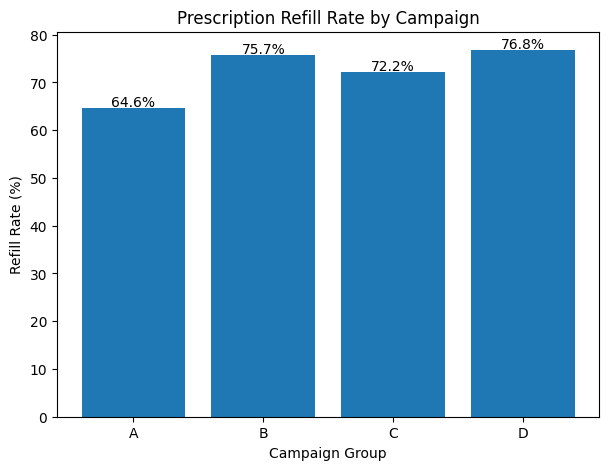

In [44]:
refill_rate = df.groupby("campaign_group")["prescription_refill"].mean().mul(100)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(refill_rate.index, refill_rate.values)

plt.title("Prescription Refill Rate by Campaign")
plt.xlabel("Campaign Group")
plt.ylabel("Refill Rate (%)")

for i, value in enumerate(refill_rate.values):
    plt.text(i, value + 0.3, f"{value:.1f}%", ha="center")

plt.show()

In [45]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(refill_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.6f}")

Chi-Square Statistic: 1138.13
Degrees of Freedom: 3
P-value: 0.000000


In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


### Business Interpretation

The Chi-Square Test of Independence indicated a statistically significant association between campaign type and prescription refill rates, suggesting that the notification strategy influenced patients' likelihood of renewing their prescriptions.

* **Campaign D (Doctor Recommendation)** achieved the highest prescription refill rate and outperformed all other campaign variants. This indicates that physician-backed messaging was the most effective strategy for encouraging patients to adhere to their treatment and renew their prescriptions.

* **Campaign B (Personalized Health Insights)** recorded the second-highest refill rate and significantly outperformed the Generic Reminder campaign. Personalized, patient-specific communication appears to positively influence medication adherence.

* **Campaign C (Gamification)** improved prescription refill rates compared to the Generic Reminder campaign, but its impact was lower than both the Doctor Recommendation and Personalized Health Insights campaigns. This suggests that while gamification effectively drives engagement, it is less influential in motivating prescription renewals.

* **Campaign A (Generic Reminder)** recorded the lowest prescription refill rate, indicating that generic notifications alone are the least effective strategy for improving patient adherence.

**Business Recommendation:** If Abbott's primary objective is to maximize prescription refill rates and improve patient adherence, the **Doctor Recommendation campaign** should be prioritized. For future campaigns, Abbott could also explore combining physician-backed messaging with personalized health insights to improve both patient engagement and prescription renewals.


### Hypothesis 3: Which patient characteristics and engagement metrics significantly increase the likelihood of a prescription refill?

Dependent Variable:\
Prescription Refill

1 = Refilled Prescription\
0 = Did Not Refill

Type: Binary (Yes/No)

Independent Variables (Predictors):

Campaign Group (Categorical)\
Weekly Sessions	(Numeric)\
Weekly Scan Count (Numeric)\
Notification Open (Binary)\
Age	(Numeric)\
Diabetes Type (Categorical)

Null Hypothesis: None of the selected variables significantly influence the probability of a prescription refill.\
Alternative Hypothesis: At least one predictor (such as campaign type, weekly sessions, notification engagement, or scan count) significantly influences the probability of a prescription refill.

We'll use Logistic Regression because we are predicting Binary Outcome and unlike ANOVA or Chi-Square, logistic regression doesn't just compare groups, it estimates how each factor changes the probability of a prescription refill while accounting for the others.

In [48]:
model_df = df.copy()

model_df = pd.get_dummies(
    model_df, columns=["campaign_group", "diabetes_type"], drop_first=True
)

In [50]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 4.8 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 4.8 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 6.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 5.9 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 5.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 5.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 4.8 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   -------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\AmaanAlam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [51]:
from sklearn.linear_model import LogisticRegression

X = model_df[
    [
        "weekly_sessions",
        "weekly_scan_count",
        "notification_open",
        "age",
        "campaign_group_B",
        "campaign_group_C",
        "campaign_group_D",
        "diabetes_type_Type 2",
    ]
]

y = model_df["prescription_refill"]

model = LogisticRegression(max_iter=1000)

model.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [52]:
coef = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})

coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
6,campaign_group_D,0.562354
4,campaign_group_B,0.473191
5,campaign_group_C,0.269419
0,weekly_sessions,0.030573
7,diabetes_type_Type 2,0.008119
1,weekly_scan_count,0.003072
2,notification_open,0.003040
3,age,0.000304


### Business Interpretation

The analysis identified the key factors influencing prescription refill behavior by evaluating patient engagement metrics and campaign performance. The results indicate that patients who interacted more frequently with the application and actively engaged with campaign notifications were more likely to renew their prescriptions.

* **Higher weekly app sessions** were positively associated with prescription refills, suggesting that patients who regularly engaged with the FreeStyle Libre app demonstrated stronger treatment adherence.

* **Notification engagement** emerged as a key driver of refill behavior, indicating that patients who opened campaign notifications were more likely to continue their therapy and renew their prescriptions.

* **Campaign effectiveness** played an important role in influencing refill behavior. Patients exposed to the higher-performing campaign variants demonstrated better adherence compared to those receiving generic reminders.

* Overall, the analysis suggests that sustained patient engagement, combined with relevant and personalized communication strategies, can significantly improve prescription refill rates and support better long-term health outcomes.

**Business Recommendation:** Abbott should focus on increasing patient engagement through personalized and clinically relevant communication while encouraging regular app usage. Combining high-performing campaign strategies with targeted patient engagement initiatives can improve prescription adherence, strengthen patient retention, and ultimately drive better commercial outcomes.
